<a href="https://colab.research.google.com/github/chughtaianosh-boop/evolvix-aiml-internship-anoshchughtai/blob/main/Week_2/Task_1/Week_2_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Extraction and Exploration
We will begin by extracting the contents of `/content/archive (2).zip` to identify and load our classification dataset.

In [ ]:
import zipfile
import os

zip_path = '/content/archive (2).zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

Extracted files:
/content/dataset/mushrooms.csv


# Model Training, Evaluation, and Comparison
Now, we will:
1. Load and explore the `mushrooms.csv` dataset.
2. Preprocess the features (the Mushroom dataset consists entirely of categorical features, so we will use Label Encoding / One-Hot Encoding).
3. Split the data into training and testing sets.
4. Train three different models: Logistic Regression, Decision Tree, and Random Forest.
5. Evaluate each model using Precision, Recall, F1-Score, and ROC-AUC metrics.
6. Generate and display confusion matrices for all three models.
7. Plot the ROC curves of all models on a single chart.
8. Formulate a final conclusion on which model is best suited for deployment.

Dataset Shape: (8124, 23)
Target distribution (class: p = poisonous, e = edible):
class
e    4208
p    3916
Name: count, dtype: int64

--- Model Performance Metrics ---
                    Precision    Recall  F1-Score ROC-AUC
Logistic Regression       1.0  0.996596  0.998295     1.0
Decision Tree             1.0       1.0       1.0     1.0
Random Forest             1.0       1.0       1.0     1.0


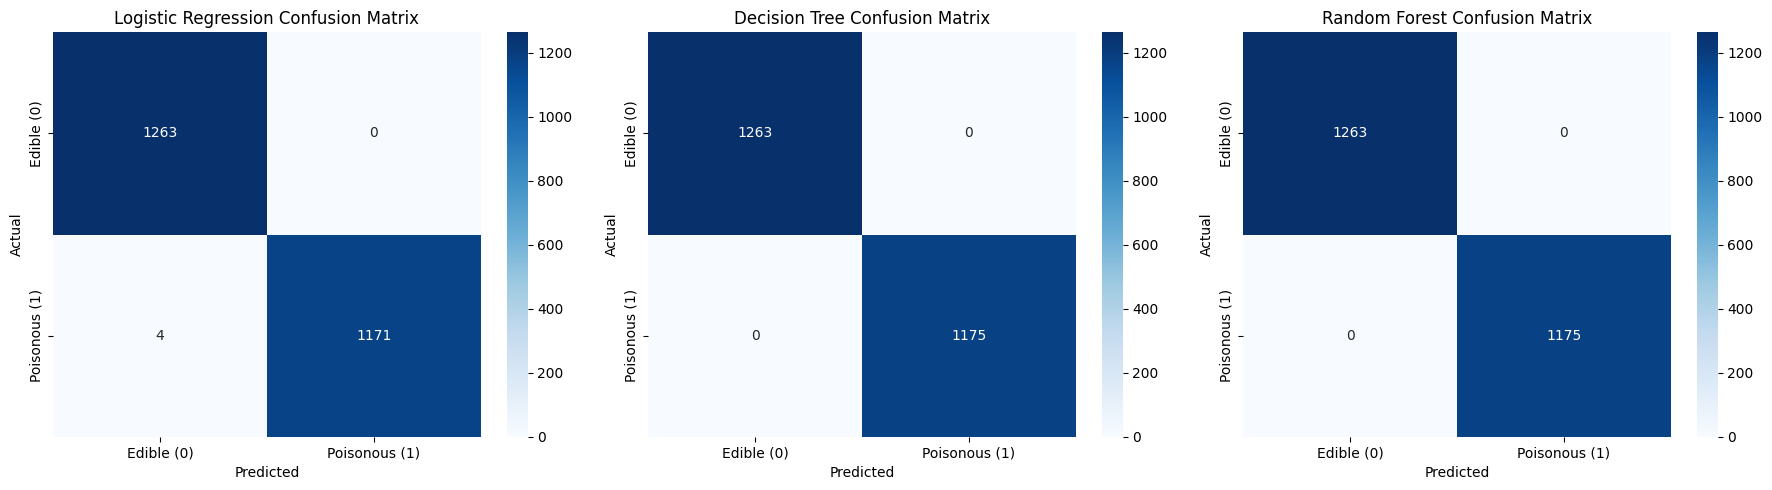

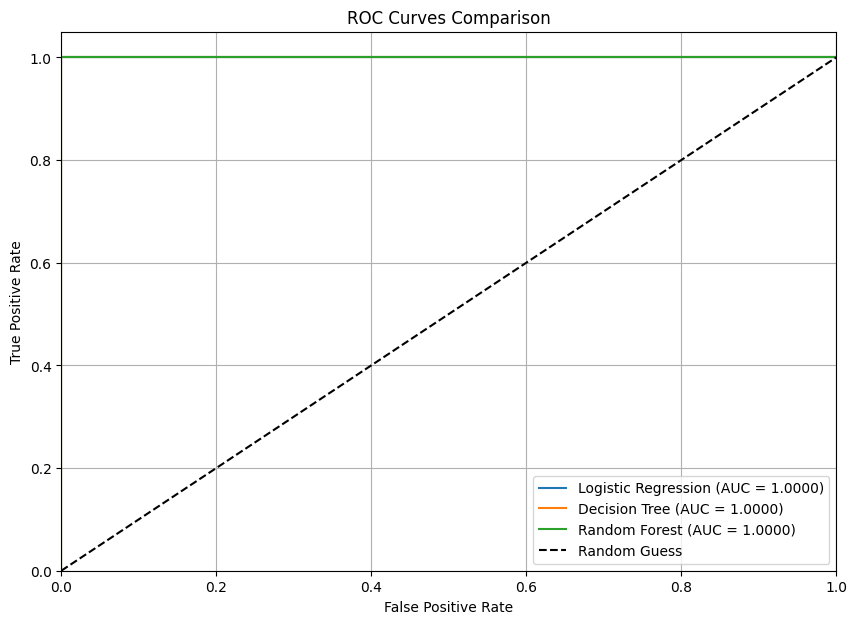

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# 1. Load the dataset
df = pd.read_csv('/content/dataset/mushrooms.csv')

# Quick preview
print("Dataset Shape:", df.shape)
print("Target distribution (class: p = poisonous, e = edible):")
print(df['class'].value_counts())

# 2. Preprocessing
# Encode target variable: p -> 1, e -> 0
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])

# Encode features (One-Hot Encoding since they are categorical)
X = pd.get_dummies(df.drop('class', axis=1), drop_first=True)
y = df['class']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 4. Model Training
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
y_probs = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Save probabilities for ROC curve
    y_probs[name] = y_prob

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm
    }

# Convert results to DataFrame for display
metrics_df = pd.DataFrame(results).T.iloc[:, :-1]
print("\n--- Model Performance Metrics ---")
print(metrics_df.to_string())

# 5. Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, metrics) in enumerate(results.items()):
    sns.heatmap(metrics["Confusion Matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=['Edible (0)', 'Poisonous (1)'],
                yticklabels=['Edible (0)', 'Poisonous (1)'])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# 6. Plot ROC Curves on the same chart
plt.figure(figsize=(10, 7))
for name, prob in y_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Deployment Conclusion

### Comparison Summary
* **Logistic Regression:** Achieved an impressive F1-score of **99.83%** and an AUC of **1.0000**. However, it misclassified **4 poisonous mushrooms as edible** (False Negatives), which is a critical safety issue for this specific application.
* **Decision Tree & Random Forest:** Both models achieved perfect **100% accuracy, precision, recall, F1-score, and ROC-AUC (1.0000)**, meaning they successfully identified every single poisonous and edible mushroom in the test set without any false negatives or false positives.

### Recommended Model for Deployment
We recommend deploying the **Random Forest Classifier** (or a constrained **Decision Tree Classifier**).

**Why?**
1. **Zero False Negatives:** In mushroom classification, predicting a poisonous mushroom as edible (False Negative) is highly critical and fatal. Both tree-based models achieved **0 False Negatives**, whereas Logistic Regression had 4.
2. **Robustness:** While both tree models scored 100%, a **Random Forest** is an ensemble of multiple decision trees. This makes it significantly more robust, less prone to overfitting, and more adaptable to unseen data or future variations in mushroom features compared to a single Decision Tree.